In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

from urllib.request import urlretrieve

urlretrieve(data, "02-car-price.csv")

('02-car-price.csv', <http.client.HTTPMessage at 0x21250816300>)

In [270]:
df = pd.read_csv("02-car-price.csv")

In [271]:
len(df)

11914

In [272]:
df.columns.str.lower().str.replace(' ', '_')

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

In [273]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [274]:
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [275]:
df.dtypes[df.dtypes == 'object']

make                 object
model                object
engine_fuel_type     object
transmission_type    object
driven_wheels        object
market_category      object
vehicle_size         object
vehicle_style        object
dtype: object

In [276]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [277]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')
    

In [278]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [279]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [280]:
import seaborn as sns


<Axes: xlabel='msrp', ylabel='Count'>

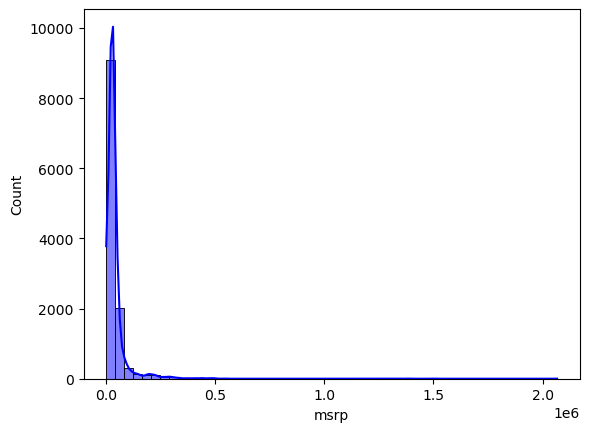

In [281]:
sns.histplot(df['msrp'], bins=50, color='blue', kde=True)

<Axes: xlabel='msrp', ylabel='Count'>

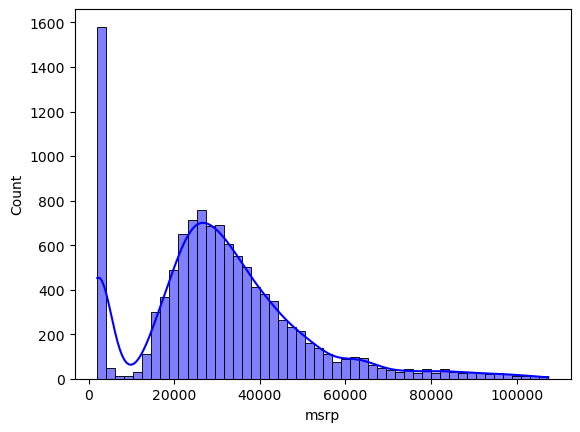

In [282]:
sns.histplot(df.msrp[df.msrp < df.msrp.quantile(0.95)], bins=50, color='blue', kde=True)

### Removing the long tail with a logarithm

In [283]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

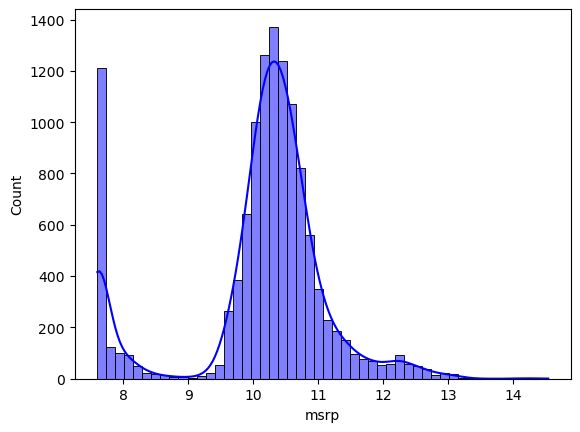

In [284]:
sns.histplot(price_logs, bins=50, color='blue', kde=True)

### Missing values

In [285]:
df.isnull().sum().sort_values(ascending=False)

market_category      3742
engine_hp              69
engine_cylinders       30
number_of_doors         6
engine_fuel_type        3
model                   0
year                    0
make                    0
driven_wheels           0
transmission_type       0
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### validation framework

In [286]:
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [287]:
n, n_train, n_val, n_test

(11914, 7150, 2382, 2382)

In [288]:
df_val = df.iloc[:n_val].copy()
df_test = df.iloc[n_val:n_val+n_test].copy()  
df_train = df.iloc[n_val+n_test:].copy()

In [289]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

### Shuffling the records

In [290]:
idx = np.arange(n)
print(idx[:10])
np.random.seed(2)
np.random.shuffle(idx)

idx[:10]

[0 1 2 3 4 5 6 7 8 9]


array([ 2735,  6720,  5878, 11190,  4554,  8001,  2882,   649,   616,
        4459])

- Now we index the dataframe with the shuffled numbers instead of the sequential ranges:

In [291]:
df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train+n_val]].copy()
df_test = df.iloc[idx[n_train+n_val:]].copy()

In [292]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

### Reset Indexes

In [293]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


### Preparing y and removing msrp

In [294]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [295]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [296]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

### The linear regression formula

- g
(
x
i
)
=
w
0
+
w
1
⋅
x
i
1
+
w
2
⋅
x
i
2
+
w
3
⋅
x
i
3

In [297]:
xi = [453, 11, 86]
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [298]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [299]:
linear_regression(xi)

12.312

In [300]:
np.expm1(linear_regression(xi))

np.float64(222347.2221101062)

### Linear regression: vector form

In [301]:
def dot (xi, w):
    n = len(xi)

    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [302]:
w_new =[w0] + w 
w_new

[7.17, 0.01, 0.04, 0.002]

In [303]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [304]:
linear_regression(xi)

12.312

### Implementing the normal equation


In [305]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)

In [306]:
XTX = X.T.dot(X)

In [307]:
XTX_inv = np.linalg.inv(XTX)

In [308]:
XTX.dot(XTX_inv).round(1)

array([[ 1.,  0.,  0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [309]:
y = [100, 200, 150, 250, 100, 200, 150, 250, 120]

In [310]:
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([0.26190562, 3.06101252, 0.03696909])

In [311]:
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])
XTX = X.T.dot(X)


In [312]:
XTX_inv = np.linalg.inv(XTX)

In [313]:
w0 = w_full[0]
w = w_full[1:]


In [314]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

### Selecting the base features

In [315]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [316]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']

In [317]:
X_train = df_train[base].values

### Dealing with missing values


In [318]:
w[:5]

array([3.06101252, 0.03696909])

In [319]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [320]:
X_train = df_train[base].fillna(0).values

### Training the model

In [321]:
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)

### Comparing the predictions with the actual prices


In [322]:
y_pred = w0 + X_train.dot(w)

y_pred[:5]

array([ 9.54792783,  9.38733977,  9.67197758,  8.65438822, 10.86602036])

<Axes: ylabel='Count'>

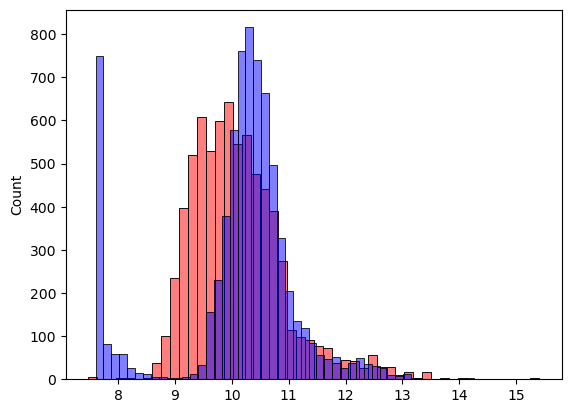

In [323]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

### Root Mean Squared Error (RMSE)

In [324]:
def rmse(y, y_pred):
    error = y-y_pred
    mse = np.mean(error ** 2)

    return np.sqrt(mse)

In [325]:
rmse(y_train, y_pred)

np.float64(0.7554192603920132)

### Preparing the feature matrix with prepare_X

In [326]:
def prepare_X (df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    return df_num.values

In [327]:
X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

In [328]:
w0, w = train_linear_regression(X_train, y_train)

### Computing the RMSE on validation data

In [329]:
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

np.float64(0.7616530991301561)

### Adding the age feature to prepare_X

In [330]:
def prepare_X(df):
    df = df.copy()
    df['age'] = 2017 - df.year

    features = base + ['age']
    df_num = df[features]
    df_num = df_num.fillna(0)

    return df_num.values

In [331]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5172055461058324)

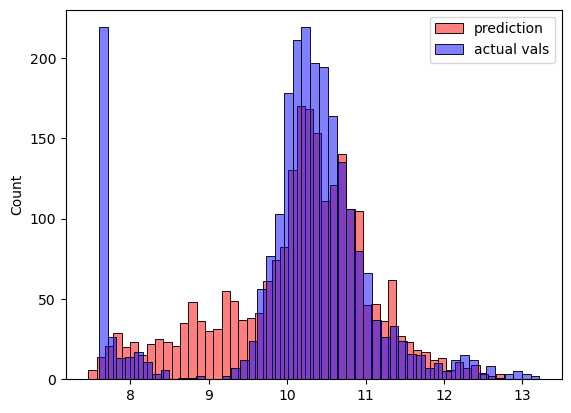

In [332]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_val, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

### Variables that are categories

In [333]:
y_pred = w0 + X_train.dot(w)

rmse(y_train, y_pred)

np.float64(0.5175055465840046)

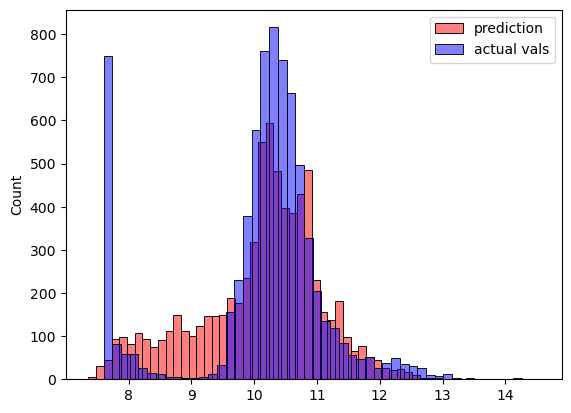

In [334]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_train, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

### Encoding categories as binary columns

- Adding doors to prepare_X

In [335]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)

    return df_num.values

In [336]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.5186588617187192)

### Doing the same for all categorical variables

In [342]:
categorical_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style'
]

categories = {}

for c in categorical_variables:
    categories[c] = list(df_train[c].value_counts().index)

In [343]:
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df.year
    features.append('age')

    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df_train.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c, v))
            
    df_num = df[features]
    df_num = df_num.fillna(0)

    return df_num.values

In [344]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

np.float64(4776.449552204369)

In [350]:
XTX = [
    [1, 2, 2],
    [2, 1, 1],
    [2, 1, 1],
]
XTX = XTX + 0.01 * np.eye(3)
np.linalg.inv(XTX)

array([[ -0.33668906,   0.33501399,   0.33501399],
       [  0.33501399,  49.91540897, -50.08459103],
       [  0.33501399, -50.08459103,  49.91540897]])

In [351]:
0.01 * np.eye(3)

array([[0.01, 0.  , 0.  ],
       [0.  , 0.01, 0.  ],
       [0.  , 0.  , 0.01]])

### The regularized training function


In [354]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [370]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r = 0.1)

X_val = prepare_X(df_val)

y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

np.float64(0.433762244075623)

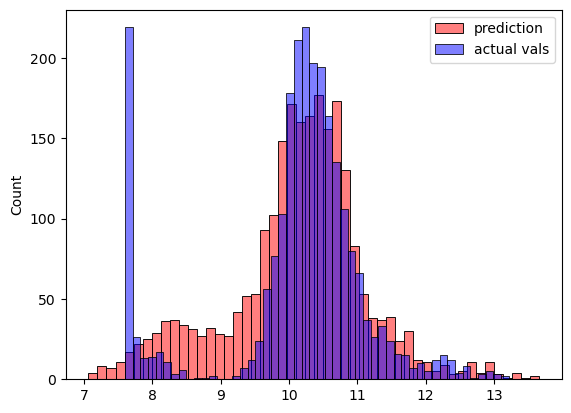

In [371]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_val, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

In [400]:

params = np.empty((0, 3))
for r in [0.0, 0.00001, 0.0001, 0.001,0.01, 0.1, 0.15,0.2, 0.25, 1, 10]:
    X_train = prepare_X(df_train)

    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val =prepare_X(df_val)

    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    params = np.vstack([params,[r, w0, score]])

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [401]:
params

array([[0.00000000e+00, 3.07815218e+17, 4.77644955e+03],
       [1.00000000e-05, 6.95371144e+00, 4.34097806e-01],
       [1.00000000e-04, 5.90259874e+00, 4.34097375e-01],
       [1.00000000e-03, 5.89420917e+00, 4.34092291e-01],
       [1.00000000e-02, 5.87031235e+00, 4.34044624e-01],
       [1.00000000e-01, 5.71297413e+00, 4.33762244e-01],
       [1.50000000e-01, 5.65286842e+00, 4.33692680e-01],
       [2.00000000e-01, 5.60105195e+00, 4.33658538e-01],
       [2.50000000e-01, 5.55471328e+00, 4.33649310e-01],
       [1.00000000e+00, 5.11812369e+00, 4.34461460e-01],
       [1.00000000e+01, 3.93975943e+00, 4.49380171e-01]])

Text(0, 0.5, 'regularization')

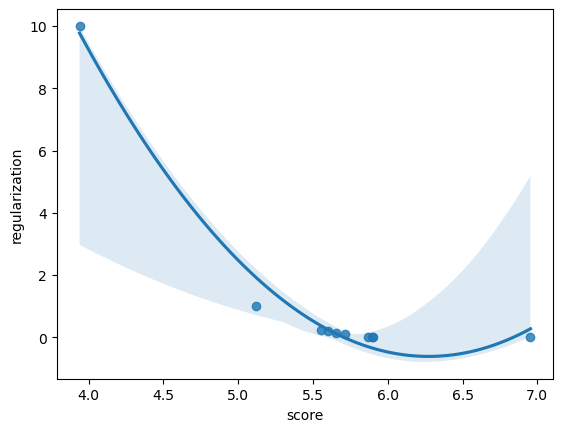

In [402]:
sns.regplot(x=params[1:, 1], y=params[1:, 0], order=2)
plt.xlabel("score")
plt.ylabel("regularization")

In [403]:
r = 0.001
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=r)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
score = rmse(y_val, y_pred)
score

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

np.float64(0.43409229112987063)

### Using the model

In [404]:
df_full_train = pd.concat([df_train, df_val])

df_full_train = df_full_train.reset_index(drop=True)

X_full_train = prepare_X(df_full_train)

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [405]:
y_full_train = np.concatenate([y_train, y_val])

In [414]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.25)

### Checking the model on test data

In [415]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

np.float64(0.3976293953131272)

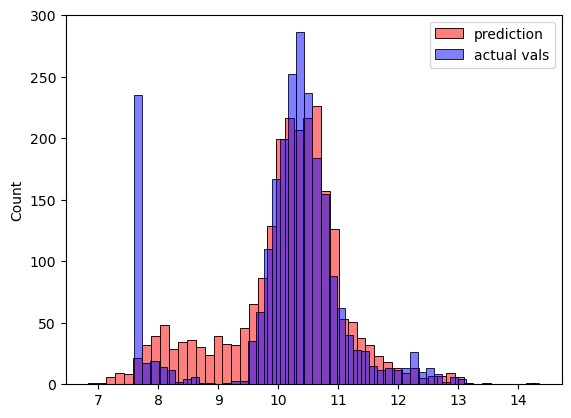

In [416]:
sns.histplot(y_pred, label = 'prediction', color = 'red', alpha = 0.5, bins=50)
sns.histplot(y_test, label = 'actual vals', color = 'blue', alpha = 0.5, bins=50)
plt.legend()

### Predicting the price of a car


In [417]:
car = df_test.iloc[20].to_dict()
car

{'make': 'toyota',
 'model': 'sienna',
 'year': 2015,
 'engine_fuel_type': 'regular_unleaded',
 'engine_hp': 266.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'automatic',
 'driven_wheels': 'front_wheel_drive',
 'number_of_doors': 4.0,
 'market_category': nan,
 'vehicle_size': 'large',
 'vehicle_style': 'passenger_minivan',
 'highway_mpg': 25,
 'city_mpg': 18,
 'popularity': 2031}

In [418]:
df_small = pd.DataFrame([car])
X_small = prepare_X(df_small)

C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
C:\Users\Samuel\AppData\Local\Temp\ipykernel_3352\3274044764.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfo

In [419]:
y_pred = w0 + X_small.dot(w)
y_pred = y_pred[0]
y_pred

np.float64(10.491241608151688)

In [420]:
np.expm1(y_pred)

np.float64(35997.826084824235)